Using Mnist dataset to predict hand written digit 

mnist → built-in dataset (handwritten digits 0–9) 
load_data() → automatically downloads & loads data

In [22]:
from tensorflow.keras.datasets import mnist

(X_train,y_train),(X_test,y_test) = mnist.load_data()

In [23]:
X_train.shape

(60000, 28, 28)

Why:  
Pixel values are from 0 to 255  
Convert to 0 to 1  
  
 Benefit:  
Faster training  
Better accuracy  

In [24]:
X_train=X_train/255.0

X_test=X_test/255.0

For CNN reshape is necessary 
CNN expects input shape:  
(samples, height, width, channels)  
In reshape  -1 lets Python automatically determine the size of that dimension during reshaping.   
(60000, 28, 28)   
After reshape    
(60000, 28, 28, 1) 

(number of images, height, width, channels) 

In [25]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

Here you can choose:  
Convert to grayscale (1 channel)  
faster  
less data  
Keep RGB (3 channels)  
more information  
better for complex tasks  

In [26]:
# Build CNN model 
from tensorflow.keras import models,layers

model = models.Sequential()
# Sequential used to add layer one after other 

In [27]:
model.add(layers.Input(shape=(28,28,1)))

model.add(layers.Conv2D(32,(3,3), activation='relu'))  
32 filters → detect features  
(3×3) → small window scanning image  
ReLU → removes negative values  
 Learns edges  

model.add(layers.MaxPool2D(2,2))  
Reduces image size  
Keeps important info  
 Example: 28×28 → 14×14

In [28]:
# First Convolution Layer
model.add(layers.Conv2D(32,(3,3), activation='relu'))
# First Pooling layer  
model.add(layers.MaxPool2D(2,2))
# Second Convolution Layer
model.add(layers.Conv2D(64,(3,3), activation='relu'))
model.add(layers.MaxPool2D(2,2))
# Flatten layer - Convert 2D->1D needed for dense layer 

model.add(layers.Flatten())  

# Dense layer - Fully connected layer learns pattern 
model.add(layers.Dense(64,activation='relu'))

# Digits = 0 to 9 → 10 classes, Softmax gives probability for each class 
model.add(layers.Dense(10,activation='softmax'))

In [18]:
model = models.Sequential()

model.add(layers.Input(shape=(28,28,1)))
model.add(layers.Conv2D(32,(3,3), activation='relu'))

In [29]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [30]:
history = model.fit(X_train,y_train,epochs=5,validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9508 - loss: 0.1622 - val_accuracy: 0.9803 - val_loss: 0.0615
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 12ms/step - accuracy: 0.9839 - loss: 0.0528 - val_accuracy: 0.9882 - val_loss: 0.0409
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9888 - loss: 0.0367 - val_accuracy: 0.9883 - val_loss: 0.0390
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.9912 - loss: 0.0274 - val_accuracy: 0.9902 - val_loss: 0.0328
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9935 - loss: 0.0195 - val_accuracy: 0.9890 - val_loss: 0.0368


In [31]:
# Evaluate Model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
# Test accuracy
print(test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9894 - loss: 0.0364 
0.9894000291824341


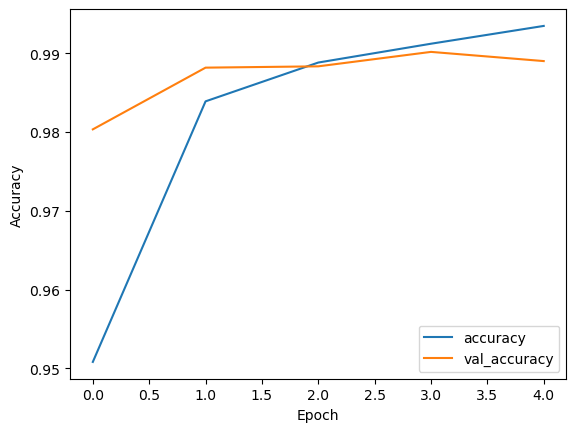

In [34]:
import matplotlib.pyplot as plt 
# Plot accuracy graph
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

In [35]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [42]:
import numpy as np 

predict_label = np.argmax(predictions[10])
print("Predicted: ",predict_label)
print("Actual: ",y_test[10])
# argmax picks the digit with highest probability

Predicted:  0
Actual:  0


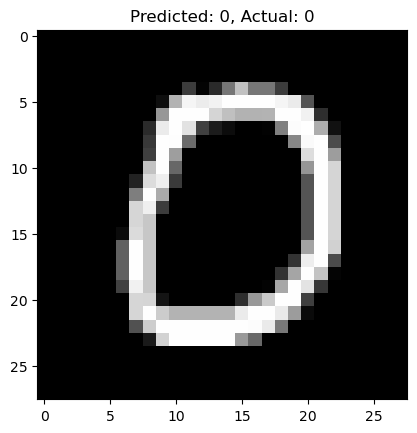

In [45]:
# Show image with prediction 
import matplotlib.pyplot as plt

plt.imshow(X_test[10].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {predict_label}, Actual: {y_test[10]}")
plt.show()